/var/folders/x4/_6bph1lx5y5_fzhpnlq6gmfw0000gn/T/ipykernel_41242/586760202.py:438: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig5, ax5 = plt.subplots(figsize=(8, 6))


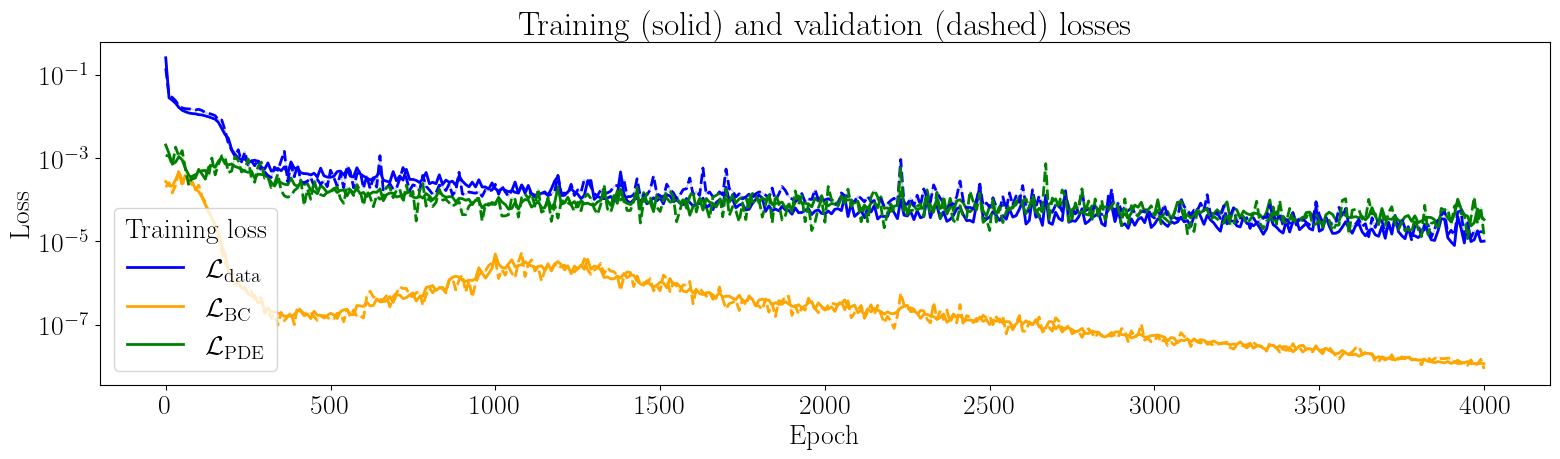

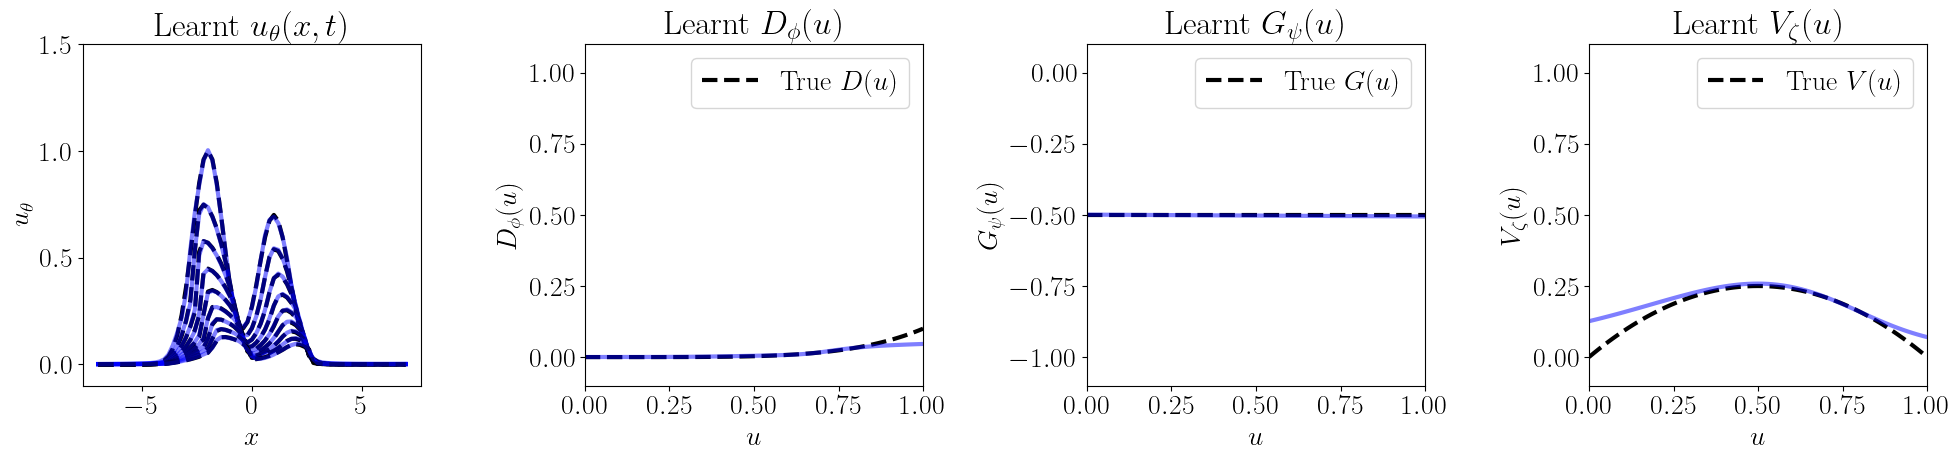

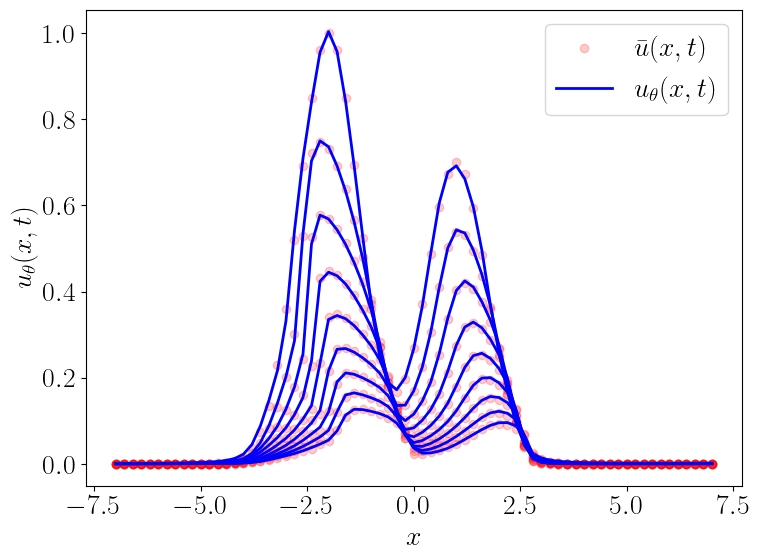

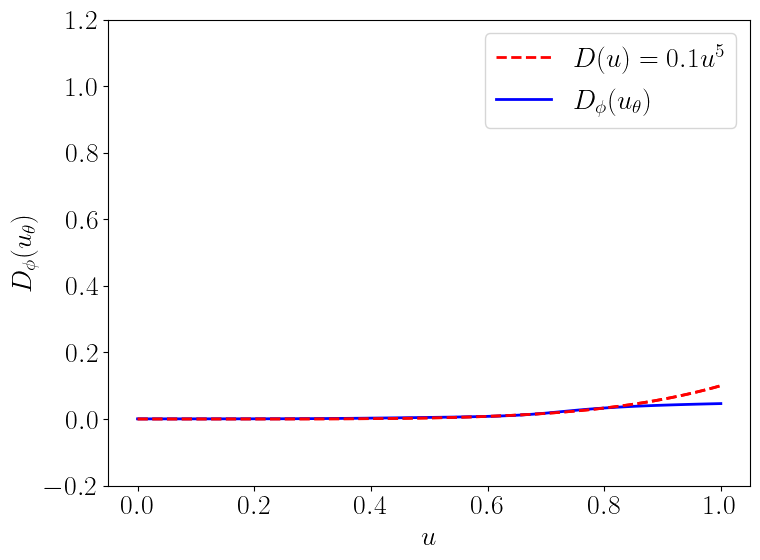

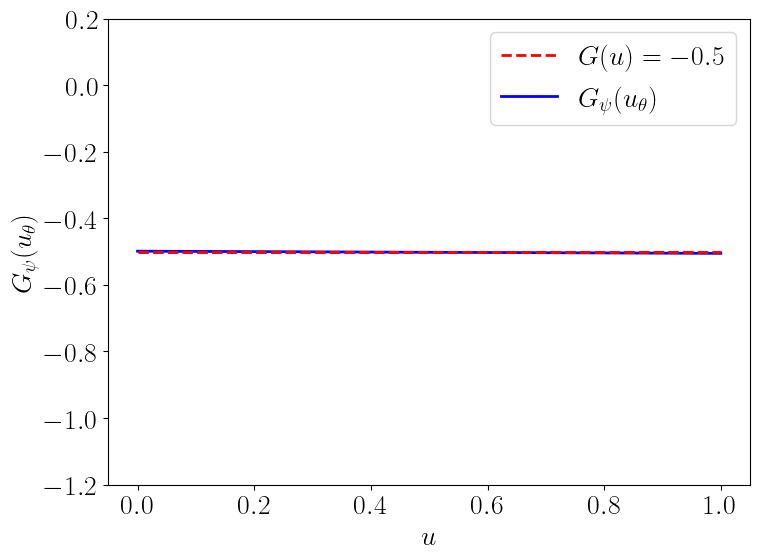

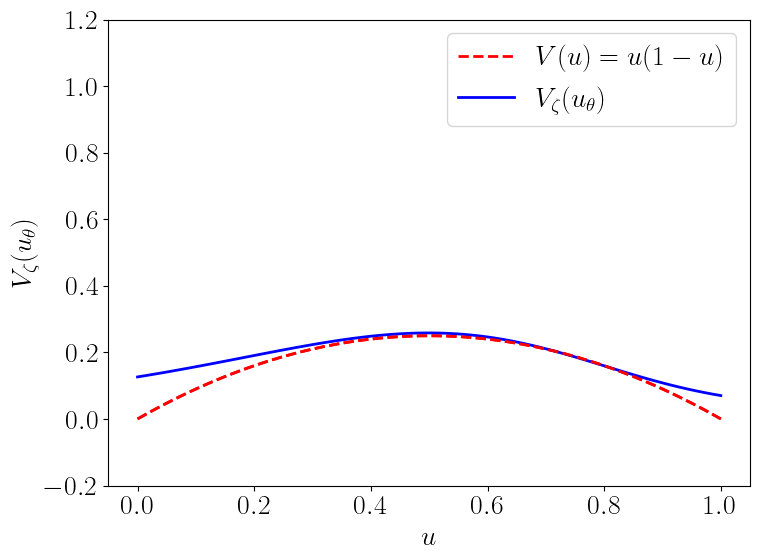

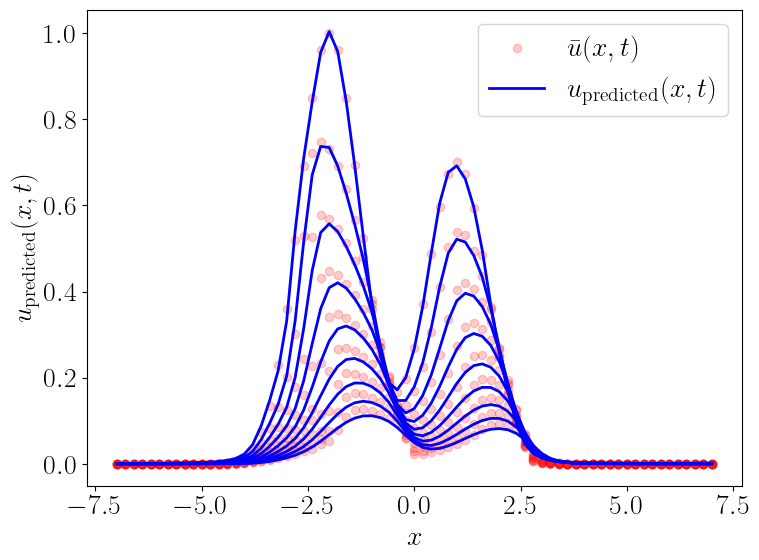

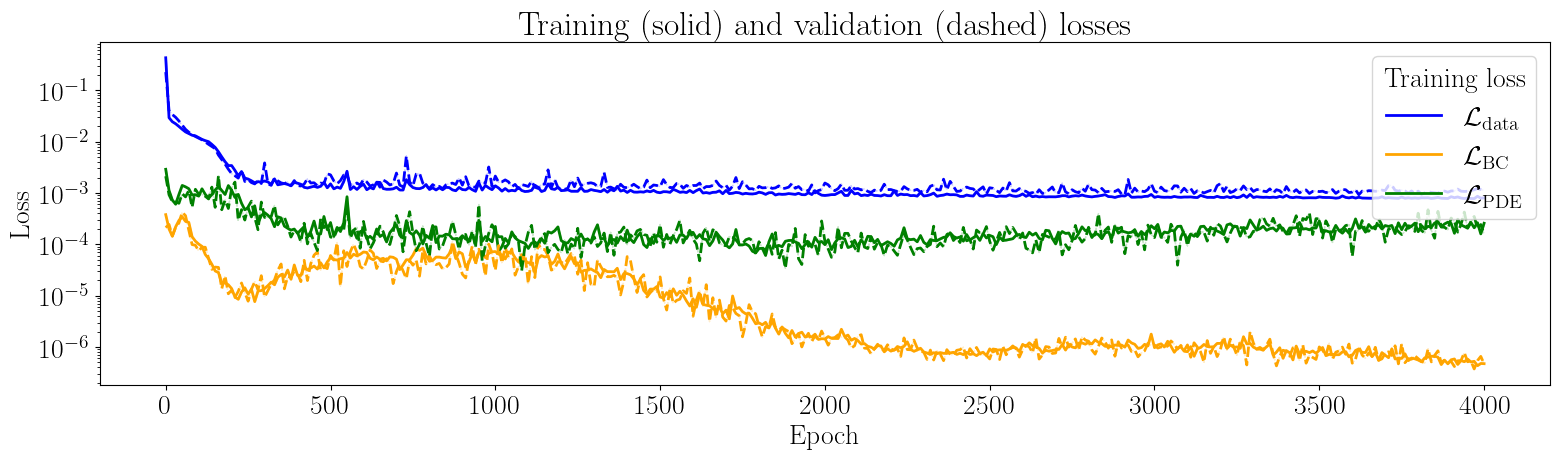

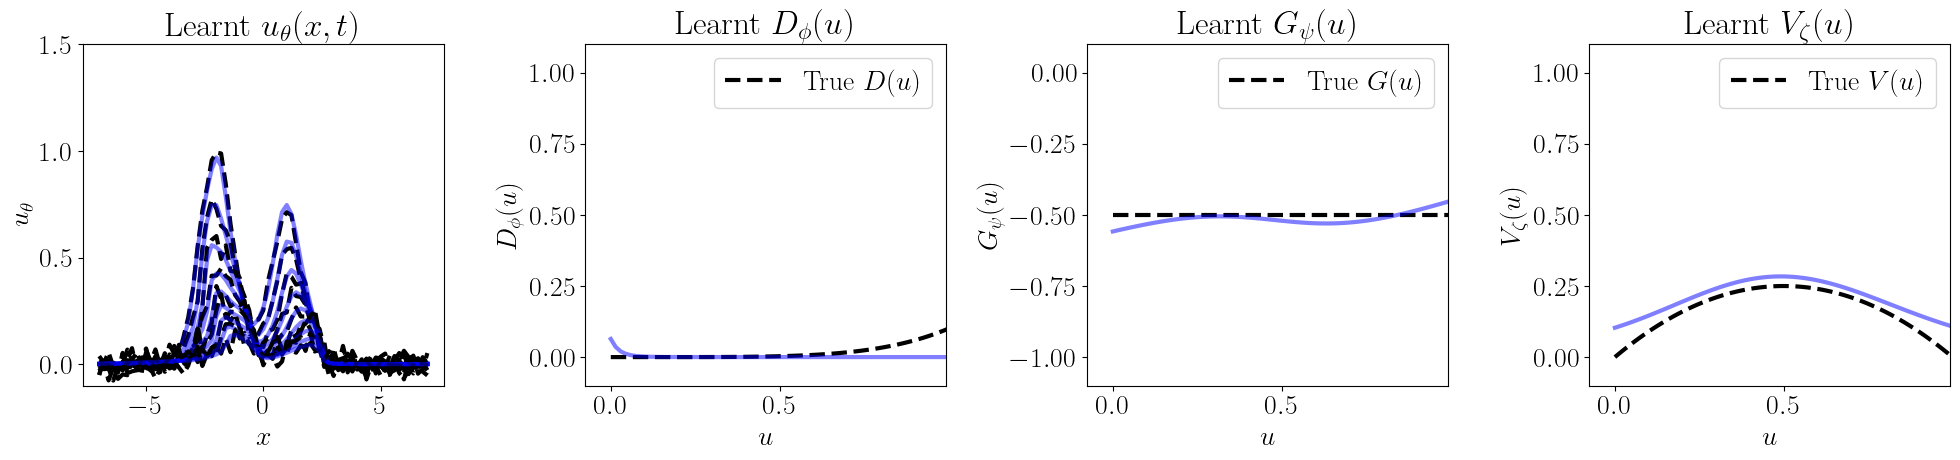

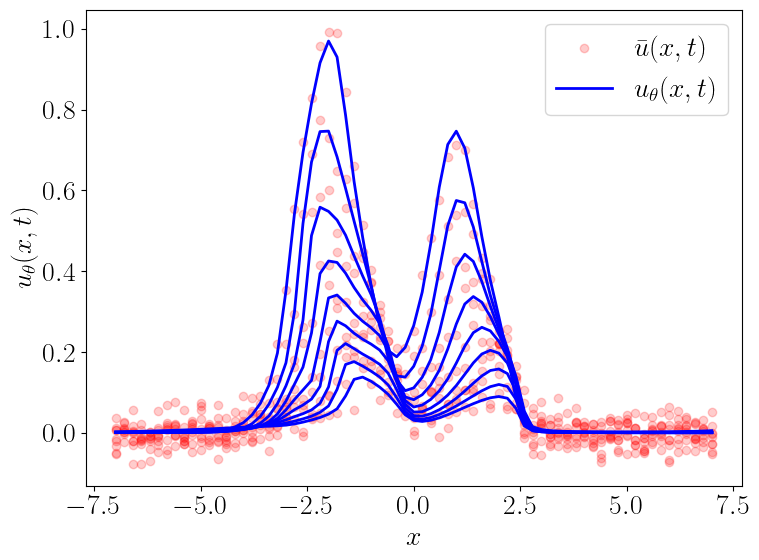

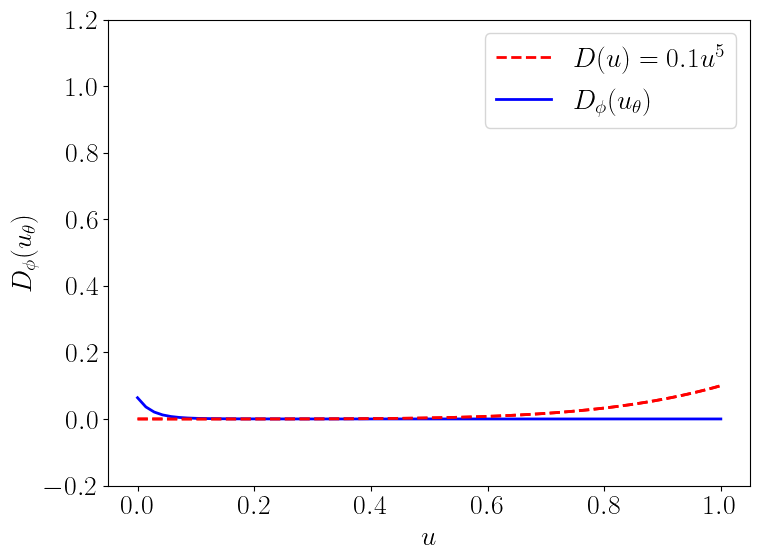

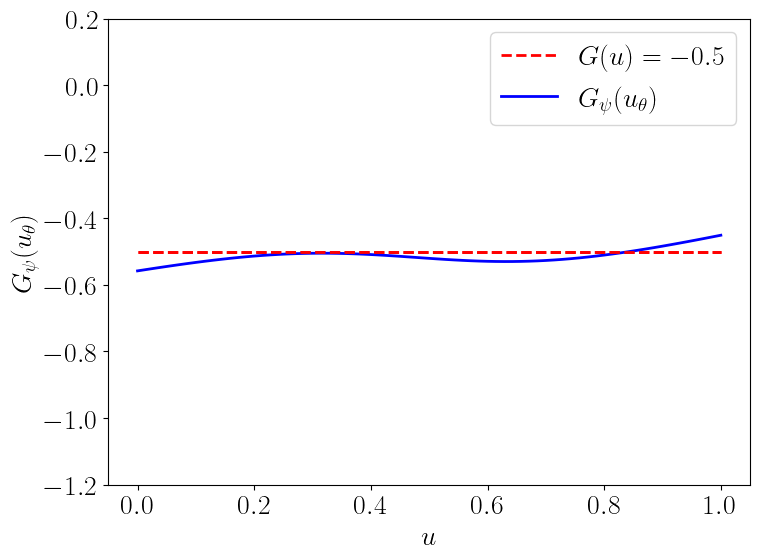

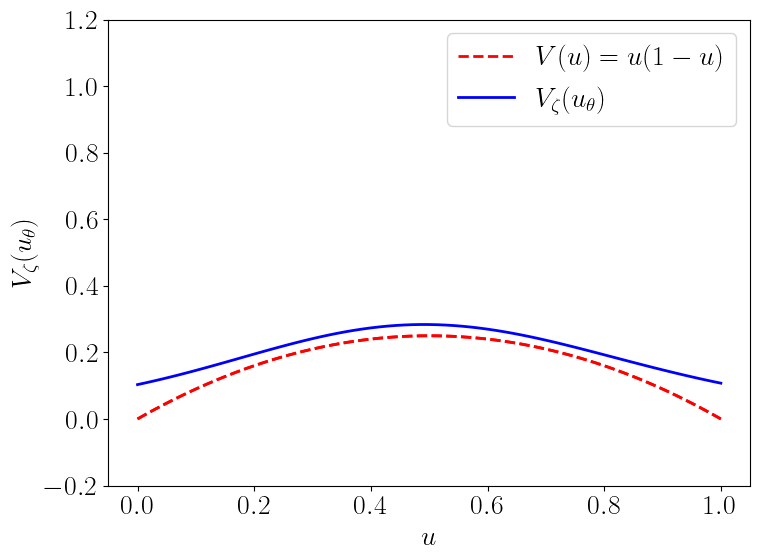

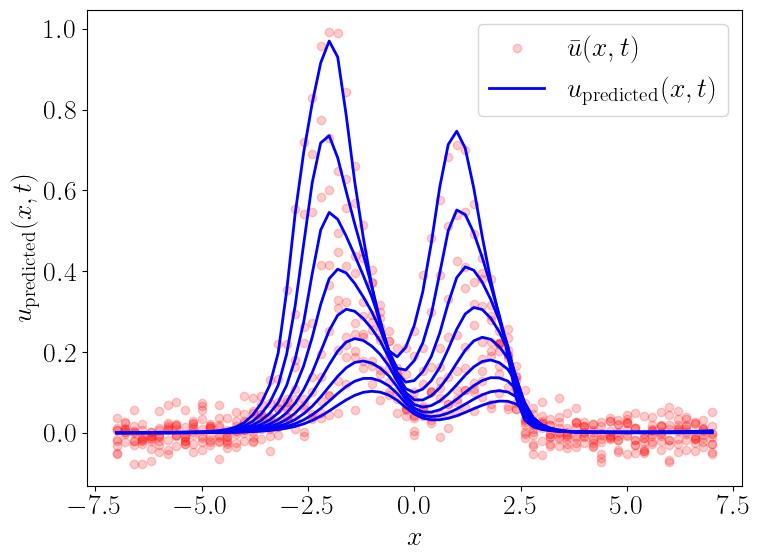

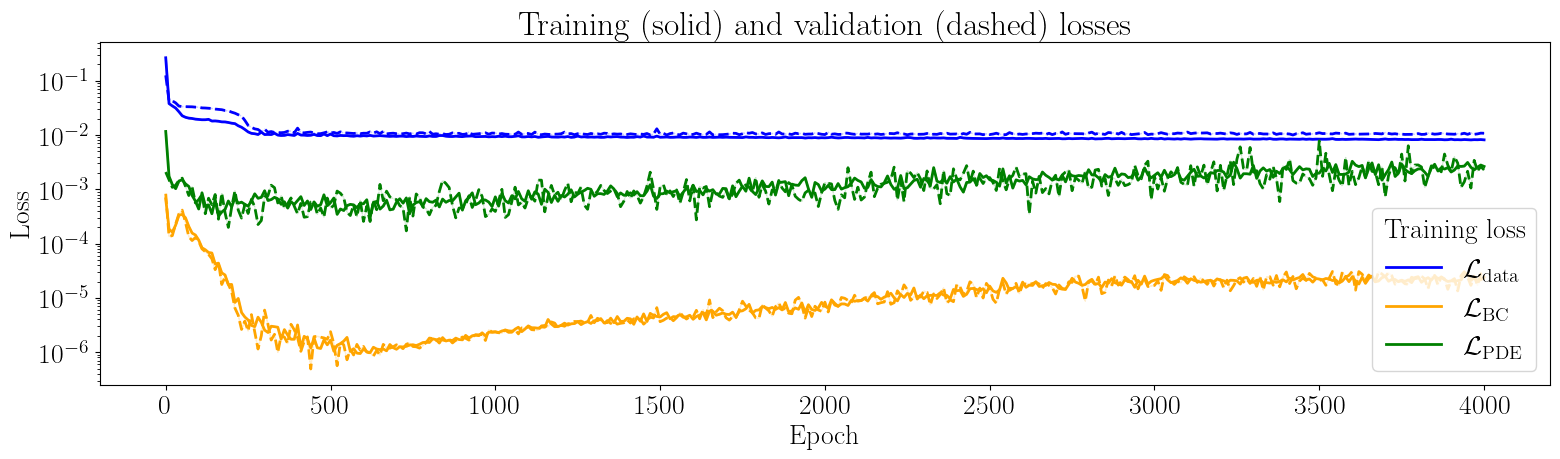

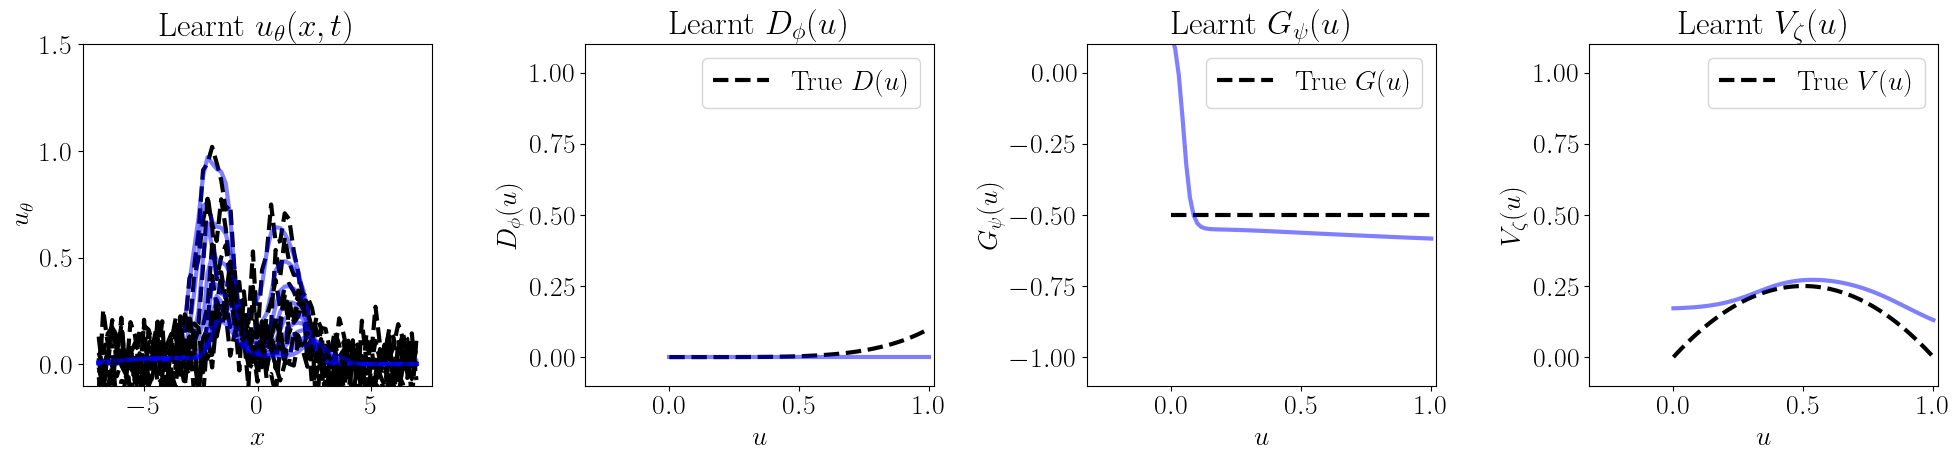

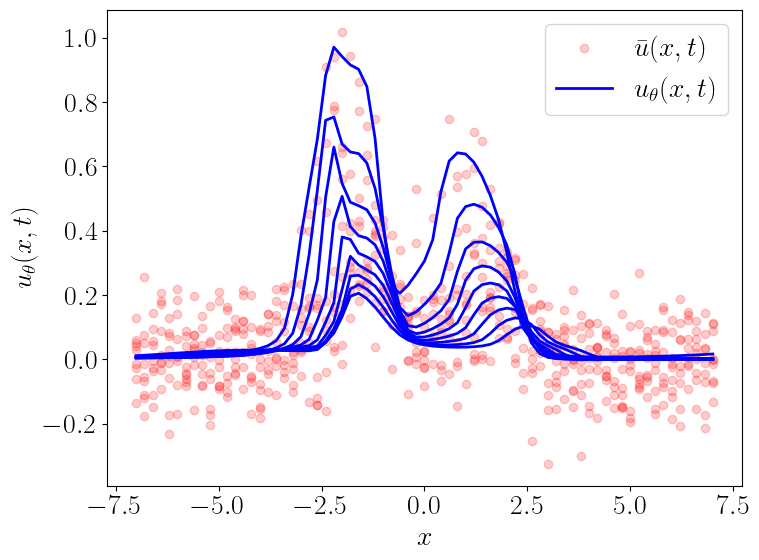

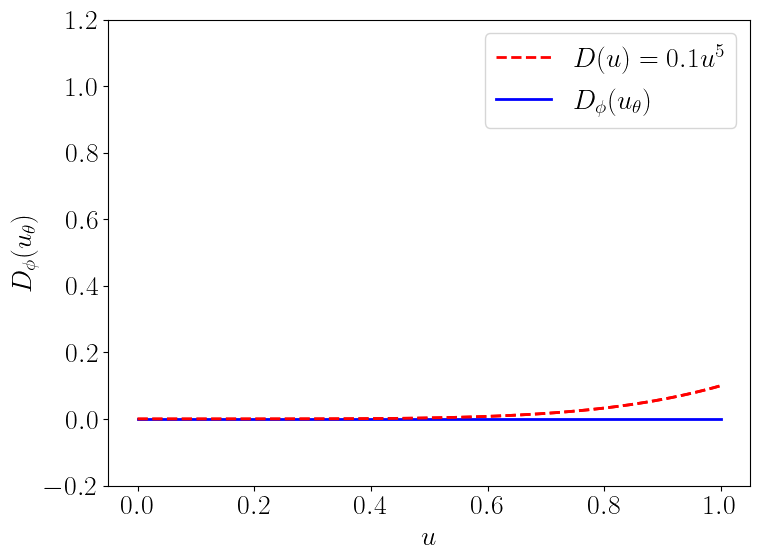

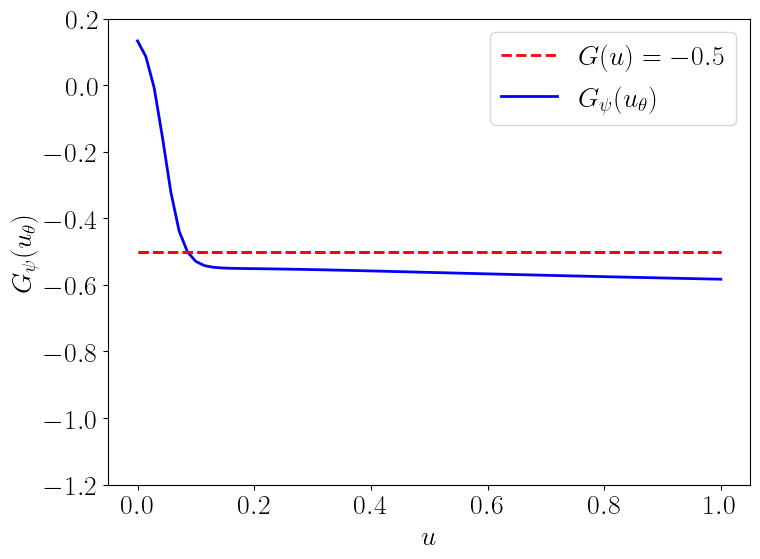

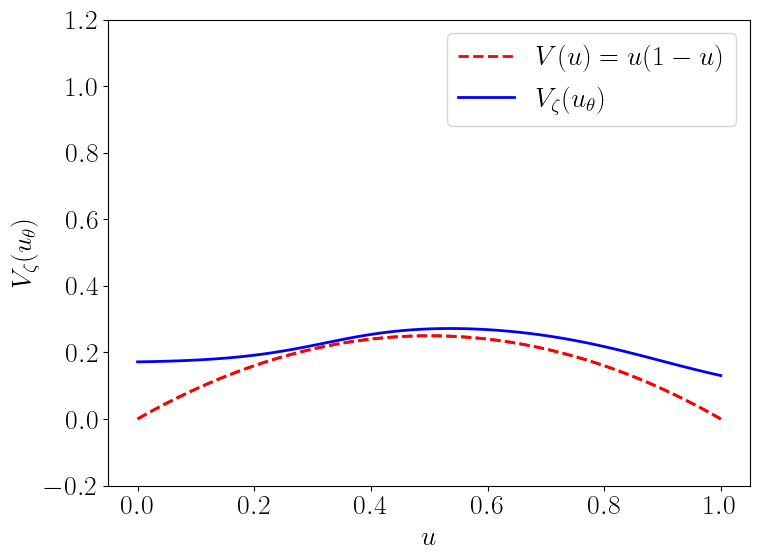

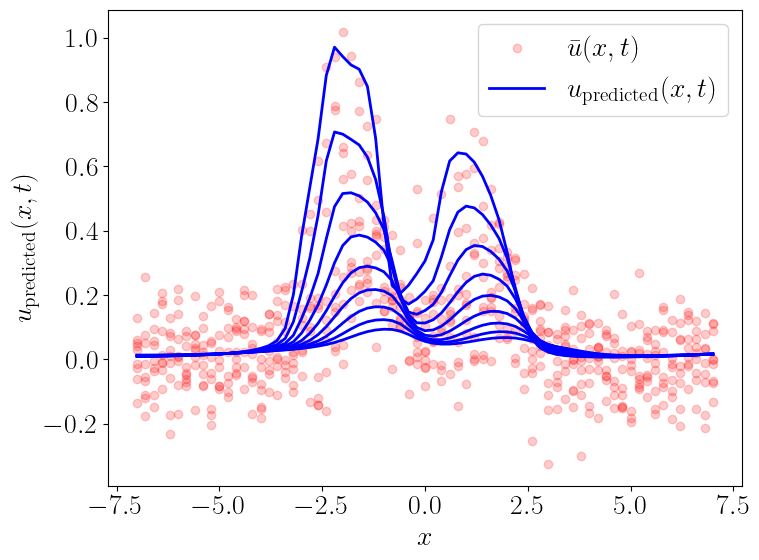

In [1]:
# import libraries and set the device
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd
import os
import sys
from torch.utils.data import TensorDataset
from scipy import integrate
from collections.abc import Callable
from typing import Tuple, Optional
from scipy.integrate import solve_ivp

from subfunction_ReactionDiffusionAdvection import *
%run subfunction_ReactionDiffusionAdvection.py

K_true = 0.5
D_base = 0.1
# plot formatting
plt.rcParams['font.family'] = 'overall_overall_times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
plt.rcParams['axes.titleweight'] = 'bold'  # Bold title
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = str(20)
plt.rcParams['lines.linewidth'] = 2
alpha_val = 0.4

def V_func(u):
    return u * (1-u)

def G_func(u):
    # Standard logistic growth: u * (1 - u/K)
    return - K_true

def D_func(u):
    # Your specific nonlinear D(u) function goes here
    return D_base * u**5
    #return D_base * (3*(u**2))  # Example: D(u) = D_base * (3*u^2)

def rhs(ti, y):
    u = np.maximum(y, 0) # Physical constraint: density cannot be negative
    
    # 1. Compute the first derivative (du/dx)
    ux = np.gradient(u, dx, edge_order=2)
    
    # 2. Compute the Velocity: V(u)
    V = V_func(u)
    
    # 3. Compute the Total Flux: J = D(u)*ux - u*V(u)
    # The negative sign inside the parenthesis in your equation becomes:
    # J = D(u) * du/dx - u * V(u)
    flux = D_func(u) * ux - u * V
    
    # 4. Enforce rho_x = 0 at the boundaries
    # This ensures the gradient is zero at both x = -L and x = +L
    ux[0] = 0
    ux[-1] = 0
    
    # 5. Compute the Divergence: d/dx(J)
    # We use np.gradient on the flux vector to get the spatial change
    diffusion_advection_term = np.gradient(flux, dx, edge_order=2)
    
    # 6. Combine with reaction term
    return diffusion_advection_term + u * G_func(u)


# Helper: wrap a PyTorch model that takes a torch tensor of shape (N,) or (N,1)
def make_torch_wrapper(pt_model, device="cpu", batch_dim=False):
    """
    Wrap a PyTorch model so it can be called as a numpy function u -> out (numpy array).
    - pt_model should accept a torch tensor of shape (N,) or (N,1) and return (N,) or (N,1)
    - device: 'cpu' or 'cuda'
    - batch_dim: if True, the model expects input shape (batch, N) or similar; keep False for elementwise
    Returns: callable(u_numpy) -> numpy array
    """
    pt_model.to(device)
    pt_model.eval()
    def wrapper(u_np: np.ndarray) -> np.ndarray:
        # Convert to torch tensor
        with torch.no_grad():
            u_t = torch.from_numpy(u_np.astype(np.float32)).to(device)
            # If model expects shape (N,1), reshape
            if u_t.ndim == 1:
                u_t_in = u_t.unsqueeze(1)  # (N,1)
            else:
                u_t_in = u_t
            out = pt_model(u_t_in)
            # If out has shape (N,1) or (N,), convert to 1D numpy
            out_np = out.detach().cpu().numpy()
            out_np = out_np.reshape(u_np.shape)
        return out_np
    return wrapper

def recon_plot(x_train, t_train, D_model, f_model, u_NN_IC, V_model):
    D_callable = make_torch_wrapper(D_model, device='cpu')
    f_callable = make_torch_wrapper(f_model, device='cpu')
    V_callable = make_torch_wrapper(V_model, device='cpu')
    u_sim = simulate_pde_new(x_train, u_NN_IC, D_callable, f_callable, V_callable,
                       t_span=(t_train[0], t_train[-1]),
                       t_eval=t_train,
                       integrator="RK45")
    return u_sim


def simulate_pde_new(x: np.ndarray,
                     IC: np.ndarray,
                     D_callable: Callable[[np.ndarray], np.ndarray],
                     f_callable: Callable[[np.ndarray], np.ndarray],
                     V_callable: Callable[[np.ndarray], np.ndarray],
                     t_span: Tuple[float, float] = (0.0, 20.0),
                     t_eval: Optional[np.ndarray] = None,
                     integrator: str = "RK45",
                     rtol: float = 1e-6,
                     atol: float = 1e-8,
                     upwind: bool = True,
                     D_average: str = "arithmetic"):
    """
    Conservative finite-volume simulator for
        u_t = ( D(u) u_x - u V(u) )_x  +  u f(u)
    on a uniform 1D vertex-centered grid with the homogeneous Neumann BC
        u_x = 0   at  x = x[0]  and  x = x[-1].

    Boundary nodes use half control volumes of length dx/2; interior nodes
    use full control volumes of length dx. At each boundary the diffusive
    contribution to the flux vanishes (u_x = 0); the advective flux at the
    boundary is -u V(u) evaluated at the boundary node (constant
    extrapolation outward, consistent with u_x = 0).

    Returns
    -------
    u_sim : np.ndarray, shape (len(t_eval), N)
    """
    x = np.asarray(x)
    if x.ndim != 1:
        raise ValueError("x must be a 1D array.")
    N = x.size

    IC = np.asarray(IC)
    if IC.shape != x.shape:
        raise ValueError("IC must have same shape as x.")

    dxs = np.diff(x)
    if np.any(dxs <= 0):
        raise ValueError("x must be strictly increasing.")
    if not np.allclose(dxs, dxs[0], rtol=1e-9, atol=0.0):
        raise ValueError("simulate_pde_new requires a uniform grid.")
    dx = float(dxs[0])

    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 201)

    def _D_iface(Dn):
        if D_average == "arithmetic":
            return 0.5 * (Dn[:-1] + Dn[1:])
        if D_average == "harmonic":
            eps = 1e-12
            return 2.0 * (Dn[:-1] * Dn[1:]) / (Dn[:-1] + Dn[1:] + eps)
        raise ValueError("D_average must be 'arithmetic' or 'harmonic'.")

    def rhs(t, u_vec):
        u  = np.asarray(u_vec, dtype=float)
        Dn = np.asarray(D_callable(u), dtype=float)
        Vn = np.asarray(V_callable(u), dtype=float)
        fu = np.asarray(f_callable(u), dtype=float)
        if Dn.shape != u.shape or Vn.shape != u.shape or fu.shape != u.shape:
            raise ValueError("D/V/f callables must return arrays the same shape as u.")

        # Interior interfaces i+1/2, i = 0, ..., N-2  (length N-1)
        D_half = _D_iface(Dn)
        V_half = 0.5 * (Vn[:-1] + Vn[1:])

        diff_int = D_half * (u[1:] - u[:-1]) / dx
        if upwind:
            u_face = np.where(V_half >= 0.0, u[:-1], u[1:])
        else:
            u_face = 0.5 * (u[:-1] + u[1:])
        adv_int = V_half * u_face
        F_int   = diff_int - adv_int                  # J = D u_x - u V at interior interfaces

        # Boundary fluxes: u_x = 0  =>  diffusive part is exactly 0 at x[0] and x[-1]
        F_left  = -u[0]  * Vn[0]
        F_right = -u[-1] * Vn[-1]

        # Conservative divergence  u_t = (J)_x  +  u f(u)
        # Interior nodes: full cells of length dx.
        # Boundary nodes: half cells of length dx/2 (vertex-centered grid).
        du = np.empty_like(u)
        du[1:-1] = (F_int[1:]  - F_int[:-1]) / dx
        du[0]    = (F_int[0]   - F_left)     / (0.5 * dx)
        du[-1]   = (F_right    - F_int[-1])  / (0.5 * dx)
        du += u * fu
        return du

    sol = solve_ivp(rhs, t_span, IC, method=integrator, t_eval=t_eval,
                    rtol=rtol, atol=atol)
    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")
    return sol.y.T


if __name__ == "__main__":

    # set the device 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

    K_true = 0.5
    D_base = 0.1

    # space resolution
    L = 7.0
    x_min, x_max = -L, L
    dx = 0.04
    x_train = np.arange(x_min, x_max+dx, dx)
    Nx = len(x_train)

    # time resolution
    Nt, t_end, t_min = 9, 4.0, 0.0
    t_train = np.linspace(t_min, t_end, Nt)
    
    # potential initial conditions (ICs) for training data generation
    def make_ic(kind, params):
        if kind == "step":
            c = params.get("center", 0.0)
            return (x_train < c).astype(float)
        if kind == "gauss":
            c = params.get("center", 0.0)
            s = params.get("sigma", 0.7)
            a = params.get("amp", 0.8)
            return a * np.exp(-0.5*((x_train-c)/s)**2)
        if kind == "bump":
            c1 = params.get("c1", -1.5)
            c2 = params.get("c2", 1.5)
            s  = params.get("sigma", 0.6)
            u0 = np.exp(-0.5*((x_train-c1)/s)**2) + 0.7*np.exp(-0.5*((x_train-c2)/s)**2)
            return np.minimum(u0, 1.0)
        raise ValueError("Unknown IC type")

    # choose one IC type and parameters for training data generation:
    kind, params = "bump", {"c1": -2.0, "c2": 1.0, "sigma": 0.7}
    u0_i = make_ic(kind, params)
    # numerically obtain the training data by solving the PDE using solve_ivp
    sol_i = integrate.solve_ivp(
    rhs, 
    (t_train[0], t_train[-1]), 
    u0_i, 
    t_eval=t_train, 
    method="RK45", 
    rtol=1e-6, 
    atol=1e-8
    )
    u_train_nonoise = sol_i.y.T # shape (Nt, Nx)
    X, T = np.meshgrid(x_train, sol_i.t)

    ## YY: subsampling: 1/5th of the datapoints (in space) ----------------------------------
    x_train = x_train[::5]
    dx = x_train[1] - x_train[0]
    Nx = len(x_train)
    X, T = np.meshgrid(x_train, t_train)
    u_train_nonoise = u_train_nonoise[:, ::5]
    

    u_min_np, u_max_np = u_train_nonoise.min(), u_train_nonoise.max()
    shape = u_train_nonoise.shape
    # Resolutions of evaluating the learnt u_net and D_net after training
    # 1). evaluate U_net at 'grid_points_tensor'
    grid_points = np.vstack([X.flatten(), T.flatten()]).T
    grid_points_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    # 2). evaluate D_net at 'U_grid_tensor'
    U_grid = np.linspace(u_min_np, u_max_np, Nx) 
    U_grid_tensor = torch.tensor(U_grid, dtype=torch.float32).to(device)
    G_true = -K_true * np.ones_like(U_grid)
    D_true = D_base * (U_grid**5)
    V_true = U_grid * (1-U_grid)

    # prepare the dataset as tensors for training
    input_data = np.concatenate([X.reshape(-1)[:, None], T.reshape(-1)[:, None]], axis=1)
    

    # Add noise to the training data
    seed = 2 # for reproducibility
    np.random.seed(seed)

    batch_size, N_pde, N_bc, N_bio = 40, 40, 40, 40
    data_weight, pde_weight, bc_weight= 1.0, 1e-1, 1e-3
    #bio_constraint_bool = True
    bio_constraint_bool = False
    u_bio_weight, D_bio_weight, G_bio_weight = 1e-1, 1e-1, 1e-1
    init_learning_rate = 5e-4
    u_num_layers, u_hidden_units = 4, 32
    u_activation_fn = nn.Tanh()
    D_num_layers, D_hidden_units = 4, 32
    D_activation_fn = nn.Tanh()
    G_num_layers, G_hidden_units = 4, 32
    G_activation_fn = nn.Tanh()
    V_num_layers, V_hidden_units = 4, 32
    V_activation_fn = nn.Tanh()
    Numrep, Num_epochs, store_loss_step = 1, 4001, 10

    train_ratio, val_ratio = 0.8, 0.1 

    variances = [0.0, 0.001, 0.01]
    
    for variance in variances:
        
        #results_dir = f'Fig1_ReactionDiffusionAdvection_var{variance}/' 
        #results_dir = f'Fig1_ReactionDiffusionAdvection_var{variance}_wbio0/' 
        results_dir = f'Fig1_ReactionDiffusionAdvection_var{variance}_subsampled_wbio0/' 
        #results_dir = f'Fig1_ReactionDiffusionAdvection_var{variance}_wbio0/' 
        save_dir = results_dir + 'ReactionDiffusionAdvection/' 
        os.makedirs(save_dir, exist_ok=True)

        noise_level = np.sqrt(variance)
        additive_noise = noise_level * np.random.randn(*shape)
        u_train_noise = u_train_nonoise + additive_noise
        u_true = u_train_noise.copy() # NOTE: no noise case
        output_data = u_train_noise.reshape(-1)[:, None]

    
        data = pd.DataFrame(np.hstack([input_data, output_data]), columns=['x', 't', 'u'])
        x_data = torch.tensor(data[['x', 't']].values, dtype=torch.float32).to(device)
        u_data = torch.tensor(data[['u']].values, dtype=torch.float32).to(device)
        # find the min and max of u for normalization
        u_min, u_max = u_data.min(), u_data.max()
        u_norm = u_max - u_min
        dataset = TensorDataset(x_data, u_data)
        # split the data into training, validation, and testing sets given different ratios
        train_size, val_size = int(len(dataset) * train_ratio), int(len(dataset) * val_ratio)
        test_size = len(dataset) - train_size - val_size
        train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])
        

        # save u_train_noise as a npy
        os.makedirs(results_dir, exist_ok=True)
        #np.save(results_dir + f'u_train_var{variance}.npy', u_train_noise)
        np.save(results_dir + f'u_train_var{variance}_subsampled.npy', u_train_noise)
        # ----------------------------------------------------------------------------------------------------

            
        TrainBINN(save_dir, device, D_true, t_end, batch_size, Numrep, Num_epochs, u_num_layers, u_hidden_units, u_activation_fn, \
              D_num_layers, D_hidden_units, D_activation_fn, init_learning_rate, data_weight, bc_weight, pde_weight, \
                N_pde, N_bc, store_loss_step, grid_points_tensor, U_grid, U_grid_tensor, t_train, x_train, u_true, X, T, Nt, u_min, u_max, \
                    N_bio, u_bio_weight, D_bio_weight, G_num_layers, G_hidden_units, G_activation_fn, G_true, bio_constraint_bool, \
                        val_dataset, test_dataset, train_dataset, x_max, x_min, t_min, G_bio_weight, V_num_layers, V_hidden_units, V_activation_fn, V_true)


        # BINNs learned results paths
        u_file_path = results_dir + f'ReactionDiffusionAdvection/Iter0/fullgrid_u_pred.npy'
        D_file_path = results_dir + f'ReactionDiffusionAdvection/Iter0/fullgrid_D_pred.npy'
        G_file_path = results_dir + f'ReactionDiffusionAdvection/Iter0/fullgrid_G_pred.npy'
        V_file_path = results_dir + f'ReactionDiffusionAdvection/Iter0/fullgrid_V_pred.npy'
        u_learned, D_learned, G_learned, V_learned = np.load(u_file_path), np.load(D_file_path), np.load(G_file_path), np.load(V_file_path)

        # predicted u from learnt 'D_net_best_Iter0.pth' and 'G_net_best_Iter0.pth'
        D_net_path = results_dir + f'ReactionDiffusionAdvection/Iter0/D_net_best_Iter0.pth'
        G_net_path = results_dir + f'ReactionDiffusionAdvection/Iter0/G_net_best_Iter0.pth'
        V_net_path = results_dir + f'ReactionDiffusionAdvection/Iter0/V_net_best_Iter0.pth'
        D_net = torch.load(D_net_path, map_location=device, weights_only=False)
        G_net = torch.load(G_net_path, map_location=device, weights_only=False)
        V_net = torch.load(V_net_path, map_location=device, weights_only=False)
        D_net.to(device)
        G_net.to(device)
        V_net.to(device)
        u_NN_IC = u_learned[0, :]
        u_recon = recon_plot(x_train, t_train, D_net, G_net, u_NN_IC, V_net)

        save_dir = results_dir + 'ReactionDiffusionAdvection/'
        dic = {
            'u_learned': u_learned,
            'D_learned': D_learned,
            'G_learned': G_learned,
            'V_learned': V_learned,
            'u_true': u_true,
            'D_true': D_true,
            'G_true': G_true,
            'V_true': V_true,
            'x_train': x_train,
            't_train': t_train,
            'U_grid': U_grid,
            'Nt': Nt,
            'u_recon': u_recon
        }
        np.save(save_dir + f'Fig1_ReactionDiffusionAdvection_data_var{variance}.npy', dic)

        # plot the results
        # plot u: 
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        for t in range(Nt):
            # scatter for true u
            ax1.scatter(x_train, u_true[t, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t)$' if t == 0 else "")
            ax1.plot(x_train, u_learned[t, :], 'blue', label=r'$u_{\theta}(x, t)$' if t == 0 else "")
        ax1.set_xlabel(r'$x$')
        ax1.set_ylabel(r'$u_{\theta}(x, t)$')
        ax1.legend()
        fig1.tight_layout()
        fig1.savefig(save_dir + 'u_NN_OneSampleRun.svg', format='svg', bbox_inches='tight')

        # plot D(u):
        fig2, ax2 = plt.subplots(figsize=(8, 6))
        ax2.plot(U_grid, D_true, 'red', label=r'$D(u)=0.1u^5$', linestyle='--') # scatter for true D(u)
        ax2.plot(U_grid, D_learned, 'blue', label=r'$D_{\phi}(u_{\theta})$')
        ax2.plot(U_grid, D_true, 'red', linestyle='--')
        ax2.set_xlabel(r'$u$')
        ax2.set_ylabel(r'$D_{\phi}(u_{\theta})$')
        ax2.legend()
        ax2.set_ylim([-0.2, 1.2])
        fig2.tight_layout()
        fig2.savefig(save_dir + 'D_NN_OneSampleRun.svg', format='svg', bbox_inches='tight')


        # plot G(u):
        fig3, ax3 = plt.subplots(figsize=(8, 6))
        ax3.plot(U_grid, G_true, 'red', label=r'$G(u)=-0.5$', linestyle='--')
        ax3.plot(U_grid, G_learned, 'blue', label=r'$G_{\psi}(u_{\theta})$')
        ax3.plot(U_grid, G_true, 'red', linestyle='--')
        ax3.set_xlabel(r'$u$')
        ax3.set_ylabel(r'$G_{\psi}(u_{\theta})$')
        ax3.legend()
        ax3.set_ylim([-1.2, 0.2])
        fig3.tight_layout()
        fig3.savefig(save_dir + 'G_NN_OneSampleRun.svg', format='svg', bbox_inches='tight')

        # plot V(u):
        fig4, ax4 = plt.subplots(figsize=(8, 6))
        ax4.plot(U_grid, V_true, 'red', label=r'$V(u)=u(1-u)$', linestyle='--')
        ax4.plot(U_grid, V_learned, 'blue', label=r'$V_{\zeta}(u_{\theta})$')
        ax4.plot(U_grid, V_true, 'red', linestyle='--')
        ax4.set_xlabel(r'$u$')
        ax4.set_ylabel(r'$V_{\zeta}(u_{\theta})$')
        ax4.legend()
        ax4.set_ylim([-0.2, 1.2])
        fig4.tight_layout()
        fig4.savefig(save_dir + 'V_NN_OneSampleRun.svg', format='svg', bbox_inches='tight')

        # plot u_predicted vs true u:
        fig5, ax5 = plt.subplots(figsize=(8, 6))
        for t in range(Nt):
            # scatter for true u
            ax5.scatter(x_train, u_true[t, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t)$' if t == 0 else "")
            ax5.plot(x_train, u_recon[t, :], 'blue', label=r'$u_{\mathrm{predicted}}(x, t)$' if t == 0 else "")
        ax5.set_xlabel(r'$x$')
        ax5.set_ylabel(r'$u_{\mathrm{predicted}}(x, t)$')
        ax5.legend()
        fig5.tight_layout()
        fig5.savefig(save_dir + 'u_reconstr_OneSampleRun.svg', format='svg', bbox_inches='tight')
